In [ ]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn import tree

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sn

In [ ]:
df = pd.read_csv('/content/multiclass_role_prediction_dataset.csv')

print(df.head())

   Python_Skill  ML_Skill  Networking_Skill  Cloud_Skill  SQL_Skill  \
0            68        45                80           88         57   
1            69        40                88           79         94   
2            56        54                69           76         36   
3            90         8                12           75         56   
4            85        71                42            4         79   

          Predicted_Role  
0  Cybersecurity Analyst  
1  Cybersecurity Analyst  
2        DevOps Engineer  
3          Web Developer  
4           Data Analyst  


In [ ]:
inputs = df.drop('Predicted_Role', axis='columns')

target = df['Predicted_Role']

In [ ]:
le_role = LabelEncoder()

target_n = le_role.fit_transform(target)

print(target_n)

[0 0 2 4 1 2 2 0 3 3 3 2 1 0 0 4 0 1 1 3 0 3 3 3 3 0 4 2 4 0 0 3 3 3 1 4 1
 3 0 2 1 1 4 0 0 3 3 4 2 4 4 1 1 2 3 3 1 4 4 3 4 3 4 4 4 2 3 2 4 3 4 4 0 3
 0 3 3 3 2 3 2 4 1 3 0 0 0 2 0 4 3 0 3 3 1 1 4 3 0 4 4 3 4 3 4 4 3 4 2 4 4
 4 4 2 4 0 4 4 2 4]


In [ ]:
print(inputs.head())

   Python_Skill  ML_Skill  Networking_Skill  Cloud_Skill  SQL_Skill
0            68        45                80           88         57
1            69        40                88           79         94
2            56        54                69           76         36
3            90         8                12           75         56
4            85        71                42            4         79


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    inputs,
    target_n,
    test_size=0.2,
    random_state=10
)

In [ ]:
model = tree.DecisionTreeClassifier()

In [ ]:
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
accuracy = model.score(X_test, y_test)

print("\nModel Accuracy:")
print(accuracy)

y_predicted = model.predict(X_test)

print("\nPredicted Outputs:")
print(y_predicted)


Model Accuracy:
0.9166666666666666

Predicted Outputs:
[3 3 4 0 4 1 4 4 2 4 2 1 1 0 2 0 3 4 4 4 4 1 3 3]



Confusion Matrix:
[[3 0 0 0 0]
 [0 4 0 0 1]
 [0 0 3 0 1]
 [0 0 0 5 0]
 [0 0 0 0 7]]


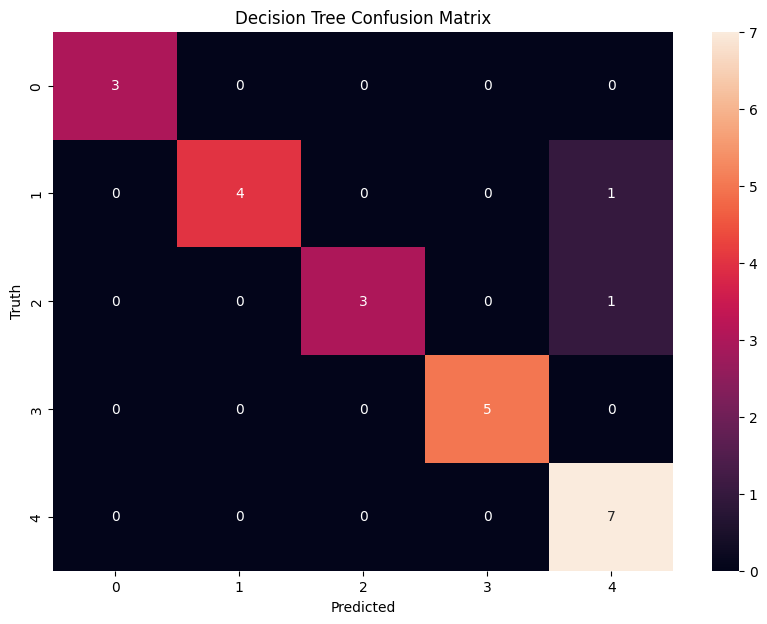

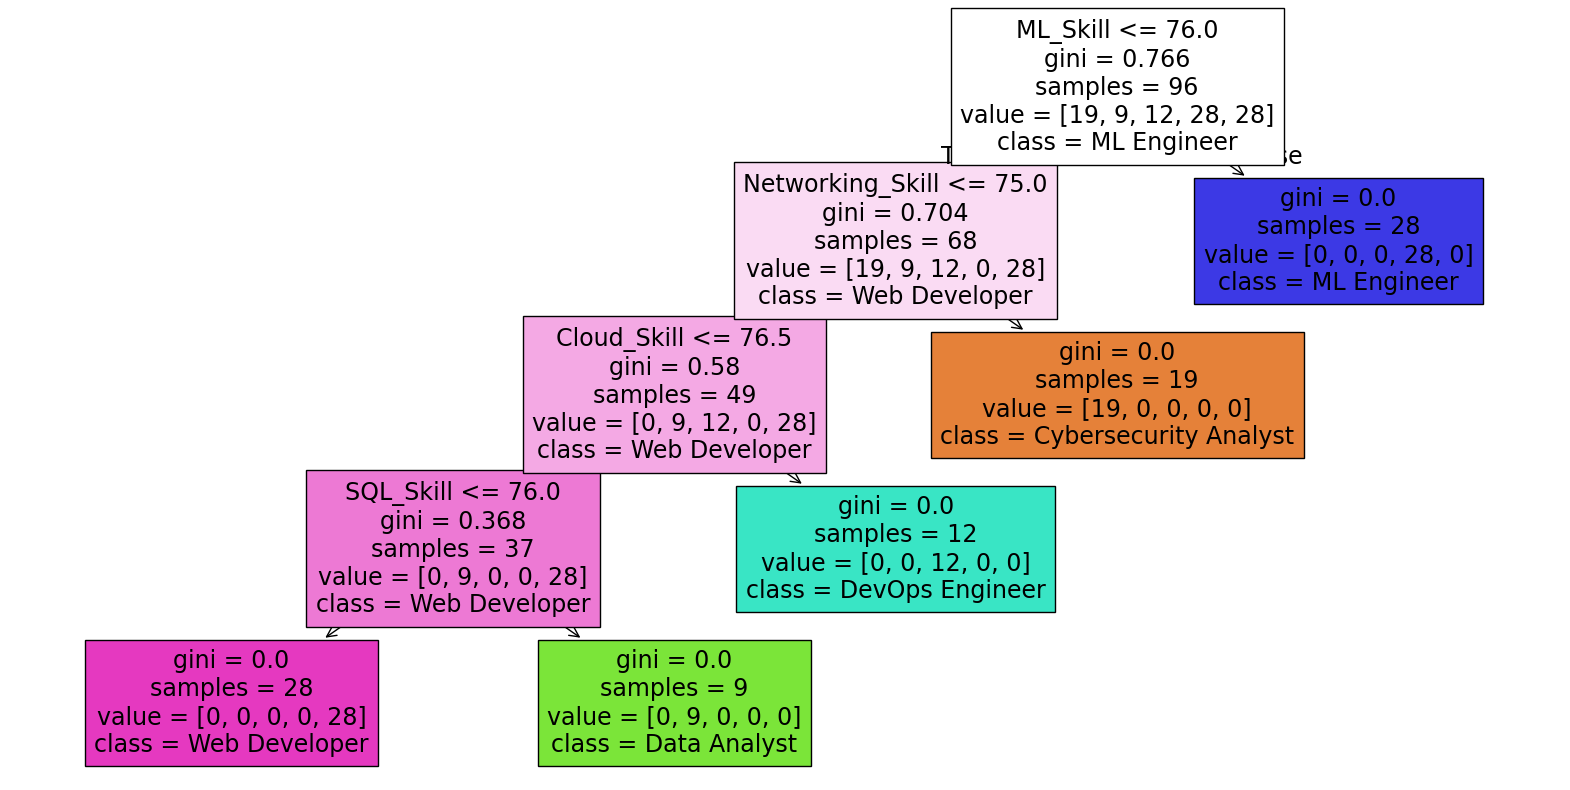


Predicted Role:
['ML Engineer']

Predicted Role:
['Cybersecurity Analyst']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
cm = confusion_matrix(y_test, y_predicted)

print("\nConfusion Matrix:")
print(cm)



plt.figure(figsize=(10,7))

sn.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Truth')

plt.title('Decision Tree Confusion Matrix')

plt.show()


plt.figure(figsize=(20,10))

tree.plot_tree(
    model,
    feature_names=inputs.columns,
    class_names=le_role.classes_,
    filled=True
)

plt.show()



prediction = model.predict([[85, 92, 20, 30, 75]])

print("\nPredicted Role:")

print(le_role.inverse_transform(prediction))



prediction2 = model.predict([[40, 20, 90, 35, 50]])

print("\nPredicted Role:")

print(le_role.inverse_transform(prediction2))